In [1]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [2]:
# Device agnostic code
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = "cpu"
print(f"Using device = {device}")

Using device = cpu


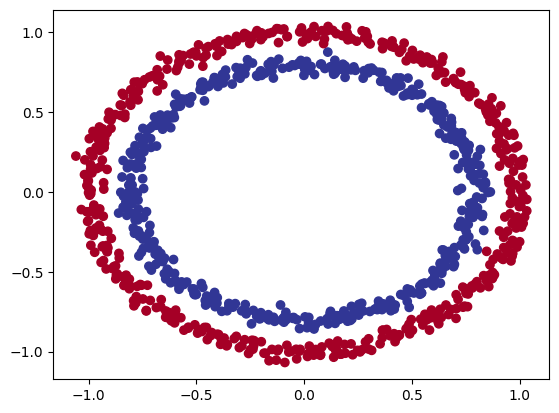

In [3]:
n_samples=1000
X,y=make_circles(n_samples=n_samples,noise=0.03,random_state=42)
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu);

In [4]:
print("Before",type(X),type(y))
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
print("After",type(X),type(y))

Before <class 'numpy.ndarray'> <class 'numpy.ndarray'>
After <class 'torch.Tensor'> <class 'torch.Tensor'>


In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

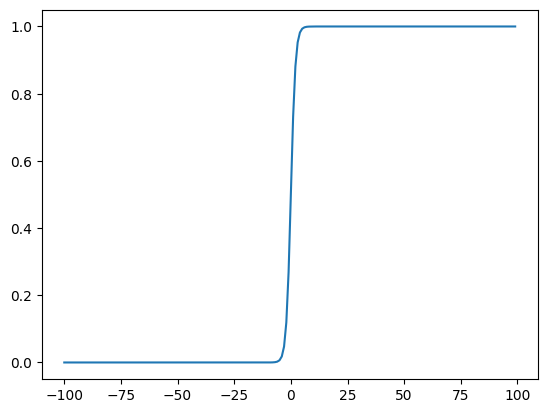

In [6]:
#Sigmod Function

def sigmoid(x):
    return 1/(1+np.exp(-x))

val1=range(-100,100)
val2=[sigmoid(val) for val in val1]
plt.plot(val1,val2);

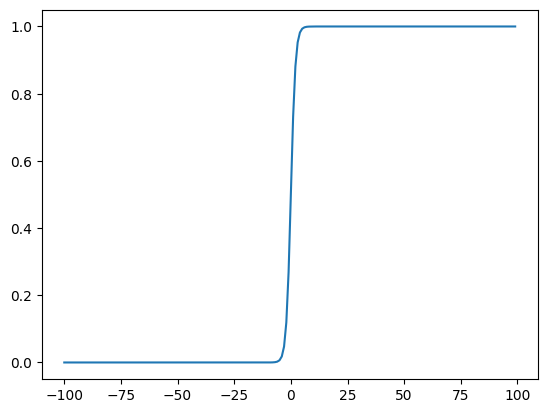

In [7]:
#Sigmod Function

def relu(x):
    return 1/(1+np.exp(-x))

val1=range(-100,100)
val2=[relu(val) for val in val1]
plt.plot(val1,val2);

In [8]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [9]:
model=CircleModel()
model.to(device)

CircleModel(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [10]:
model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.0211, -0.6093],
                      [ 0.4462, -0.3593],
                      [-0.1651,  0.5405],
                      [ 0.0167,  0.6166],
                      [ 0.1538,  0.2026],
                      [-0.3216,  0.6449],
                      [ 0.4823,  0.2582],
                      [ 0.2467,  0.4337],
                      [-0.4698, -0.3003],
                      [ 0.4657, -0.6588]])),
             ('layer_1.bias',
              tensor([ 0.4696,  0.6192,  0.4414,  0.3101, -0.1041,  0.3675,  0.1189,  0.4448,
                      -0.5481, -0.5488])),
             ('layer_2.weight',
              tensor([[-0.0627,  0.2509, -0.2623,  0.1724,  0.0064,  0.3078,  0.1973,  0.2336,
                        0.2564, -0.2698],
                      [ 0.0651,  0.0357, -0.1821,  0.0787, -0.0391, -0.1772, -0.1119, -0.3141,
                       -0.3046, -0.0857],
                      [ 0.1143, -0.2702, -0.2979, -0.0667,  0.0442, -0.1

In [11]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    params=model.parameters(), lr=0.05
)

In [12]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc

In [13]:
epochs=3000
torch.manual_seed(42)
trainLossList=[]
testLossList=[]
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)
for epoch in range(epochs):
     ### Training
    model.train()

    # 1. Forward Pass
    y_logits = model(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    # 2. Compute training loss
    train_loss = loss_fn(y_logits, y_train)

    # 3. Zero grad the optimizer
    optimizer.zero_grad()
    # 4. Backpropagate
    train_loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    ### Testing
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

    trainLossList.append(train_loss.cpu().detach().numpy())
    testLossList.append(test_loss.cpu().detach().numpy())
    if epoch%100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {train_loss:.5f} | Train Acc: {acc:.2f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")


Epoch: 0 | Train Loss: 0.70295 | Train Acc: 50.00 | Test Loss: 0.70271 | Test Acc: 50.00
Epoch: 100 | Train Loss: 0.69416 | Train Acc: 50.00 | Test Loss: 0.69447 | Test Acc: 50.00
Epoch: 200 | Train Loss: 0.69289 | Train Acc: 48.75 | Test Loss: 0.69339 | Test Acc: 45.00
Epoch: 300 | Train Loss: 0.69184 | Train Acc: 55.00 | Test Loss: 0.69251 | Test Acc: 54.00
Epoch: 400 | Train Loss: 0.69088 | Train Acc: 58.00 | Test Loss: 0.69171 | Test Acc: 57.50
Epoch: 500 | Train Loss: 0.68973 | Train Acc: 58.50 | Test Loss: 0.69071 | Test Acc: 56.00
Epoch: 600 | Train Loss: 0.68868 | Train Acc: 58.25 | Test Loss: 0.68980 | Test Acc: 55.50
Epoch: 700 | Train Loss: 0.68748 | Train Acc: 57.88 | Test Loss: 0.68877 | Test Acc: 54.00
Epoch: 800 | Train Loss: 0.68604 | Train Acc: 59.00 | Test Loss: 0.68752 | Test Acc: 55.50
Epoch: 900 | Train Loss: 0.68427 | Train Acc: 58.75 | Test Loss: 0.68608 | Test Acc: 57.00
Epoch: 1000 | Train Loss: 0.68206 | Train Acc: 58.88 | Test Loss: 0.68437 | Test Acc: 57.50


In [14]:
model.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model(X_test))).squeeze()
print(y_preds)

tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0.,
        1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1.,
        1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
        1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
        0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0.,
        1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.,
        0., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1.,
        1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
        0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0.,
        1., 1.])


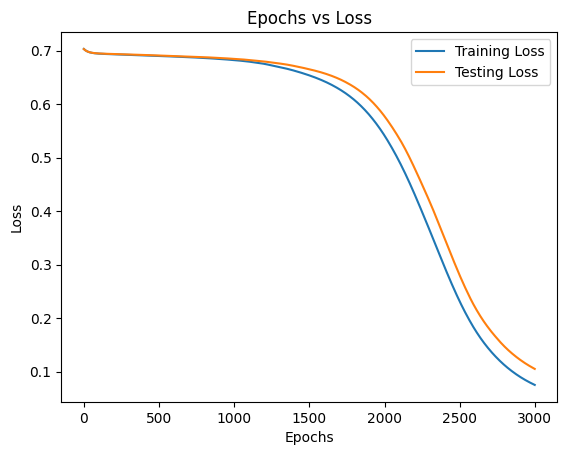

In [15]:
# Plot the Epochs vs Loss plot
plt.plot(range(epochs), trainLossList, label="Training Loss")
plt.plot(range(epochs), testLossList, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Epochs vs Loss")
plt.legend()
plt.show()

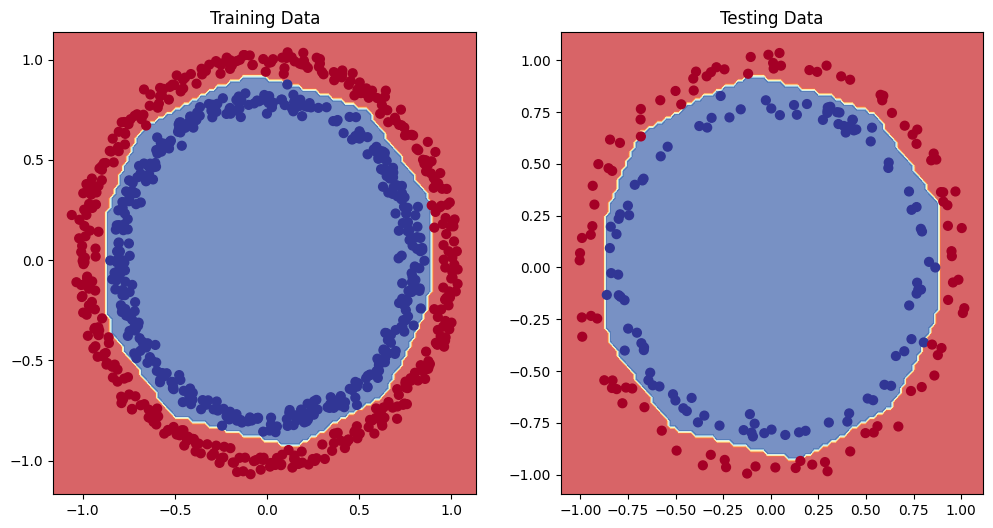

In [16]:
from helper_functions import plot_decision_boundary
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)